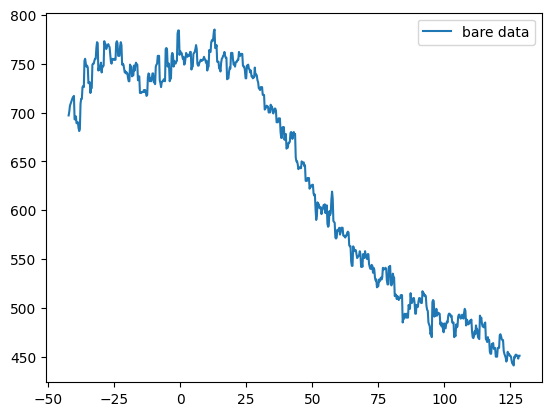

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

csv_path = Path("../data/nb_of_cells.csv")
df = pd.read_csv(csv_path)


t = df["time"].to_numpy()
N_cells = df["N_total"].to_numpy()


plt.plot(t, N_cells, label = "cell number")
plt.legend()
plt.show()

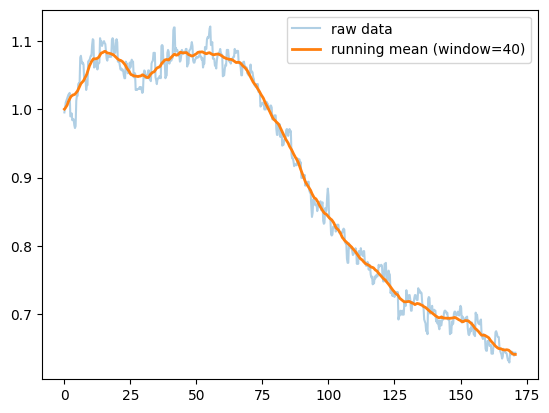

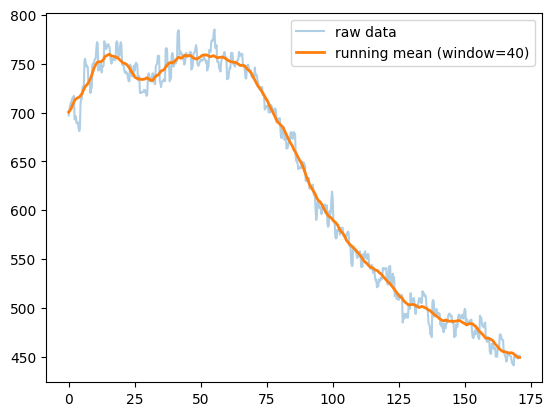

In [16]:
window = 40 #11  # number of measurements; choose odd so it is centered

N_smooth = (
    pd.Series(N_cells)
    .rolling(window=window, center=True, min_periods=1)
    .mean()
    .to_numpy()
)
N_start = N_smooth[0]
t_start = t[0]
t -= t_start

plt.plot(t, N_cells/N_start, alpha=0.35, label="raw data")
plt.plot(t, N_smooth/N_start, lw=2, label=f"running mean (window={window})")
plt.legend()
plt.show()


plt.plot(t, N_cells, alpha=0.35, label="raw data")
plt.plot(t, N_smooth, lw=2, label=f"running mean (window={window})")
plt.legend()
plt.show()

In [17]:
save_path = Path("../data/nb_of_cells_reg.csv")

pd.DataFrame({
    "time": t,
    "cell_fraction_regularized": N_smooth/N_start,
}).to_csv(save_path, index=False)